# Лабораторная работа: Подготовка обучающей и тестовой выборки, кросс-валидация и подбор гиперпараметров на примере метода ближайших соседей

## Цель лабораторной работы:
Изучение способов подготовки выборки и подбора гиперпараметров на примере метода ближайших соседей.

## Задание:
1. Выберите набор данных (датасет) для решения задачи классификации или регрессии.
2. В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
3. С использованием метода `train_test_split` разделите выборку на обучающую и тестовую.
4. Обучите модель ближайших соседей для произвольно заданного гиперпараметра K. Оцените качество модели с помощью подходящих для задачи метрик.
5. Произведите подбор гиперпараметра K с использованием `GridSearchCV` и `RandomizedSearchCV` и кросс-валидации, оцените качество оптимальной модели. Используйте не менее двух стратегий кросс-валидации.
6. Сравните метрики качества исходной и оптимальной моделей.

## 1. Импорт необходимых библиотек

In [1]:
!pip install pandas scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings('ignore')


[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


## 2. Загрузка и первичный анализ данных

В качестве датасета выберем известный датасет 'Iris' для задачи классификации. Он хорошо подходит для демонстрации метода ближайших соседей и не требует сложной предобработки.

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

print("Первые 5 строк данных X:")
print(X.head())
print("\nПервые 5 значений целевой переменной y:")
print(y.head())
print("\nИнформация о датасете X:")
X.info()
print("\nСтатистическое описание датасета X:")
X.describe()

Первые 5 строк данных X:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Первые 5 значений целевой переменной y:
0    0
1    0
2    0
3    0
4    0
dtype: int64

Информация о датасете X:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: floa

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 3. Проверка на пропуски и кодирование категориальных признаков

Датасет Iris не содержит пропусков и категориальных признаков, кроме целевой переменной, которая уже представлена в числовом виде. Поэтому эта часть кода будет скорее демонстрационной, чтобы показать, как это делается в общем случае.

In [3]:
print("Количество пропусков в каждом столбце:")
print(X.isnull().sum())

# Для демонстрации, если бы были категориальные признаки и пропуски
# numerical_features = X.select_dtypes(include=np.number).columns
# categorical_features = X.select_dtypes(exclude=np.number).columns

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), numerical_features),
#         ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
#     ])

# X_processed = preprocessor.fit_transform(X)
# print("\nРазмерность данных после предобработки (если бы она была):", X_processed.shape)

Количество пропусков в каждом столбце:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


## 4. Разделение выборки на обучающую и тестовую

Разделим данные на обучающую и тестовую выборки с соотношением 80/20. `stratify=y` используется для того, чтобы сохранить пропорции классов в обучающей и тестовой выборках.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки X_train: {X_train.shape}")
print(f"Размер тестовой выборки X_test: {X_test.shape}")
print(f"Распределение классов в y_train:\n{y_train.value_counts(normalize=True)}")
print(f"Распределение классов в y_test:\n{y_test.value_counts(normalize=True)}")

Размер обучающей выборки X_train: (120, 4)
Размер тестовой выборки X_test: (30, 4)
Распределение классов в y_train:
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64
Распределение классов в y_test:
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64


## 5. Обучение модели K-ближайших соседей для произвольного K

Обучим модель `KNeighborsClassifier` с произвольно выбранным `K=5` и оценим её качество.

Качество модели с K = 5:
Accuracy: 1.0000
Precision (macro avg): 1.0000
Recall (macro avg): 1.0000
F1-score (macro avg): 1.0000

Отчет по классификации:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



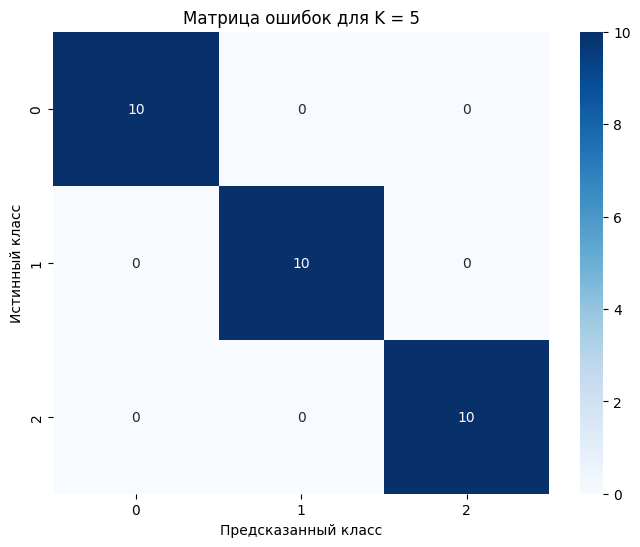

In [5]:
k_arbitrary = 5
knn_arbitrary = KNeighborsClassifier(n_neighbors=k_arbitrary)
knn_arbitrary.fit(X_train, y_train)

y_pred_arbitrary = knn_arbitrary.predict(X_test)

print(f"Качество модели с K = {k_arbitrary}:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_arbitrary):.4f}")
print(f"Precision (macro avg): {precision_score(y_test, y_pred_arbitrary, average='macro'):.4f}")
print(f"Recall (macro avg): {recall_score(y_test, y_pred_arbitrary, average='macro'):.4f}")
print(f"F1-score (macro avg): {f1_score(y_test, y_pred_arbitrary, average='macro'):.4f}")

print("\nОтчет по классификации:")
print(classification_report(y_test, y_pred_arbitrary))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_arbitrary), annot=True, fmt='d', cmap='Blues')
plt.title(f'Матрица ошибок для K = {k_arbitrary}')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

## 6. Подбор гиперпараметра K с использованием GridSearchCV и RandomizedSearchCV

Используем две стратегии кросс-валидации: `KFold` и `StratifiedKFold`.

### 6.1. Подбор K с помощью GridSearchCV

`GridSearchCV` выполняет исчерпывающий поиск по заданной сетке значений гиперпараметров.

GridSearchCV с KFold:
Лучшее значение K: 6
Лучшая точность на кросс-валидации: 0.9583

GridSearchCV со StratifiedKFold:
Лучшее значение K: 14
Лучшая точность на кросс-валидации: 0.9750


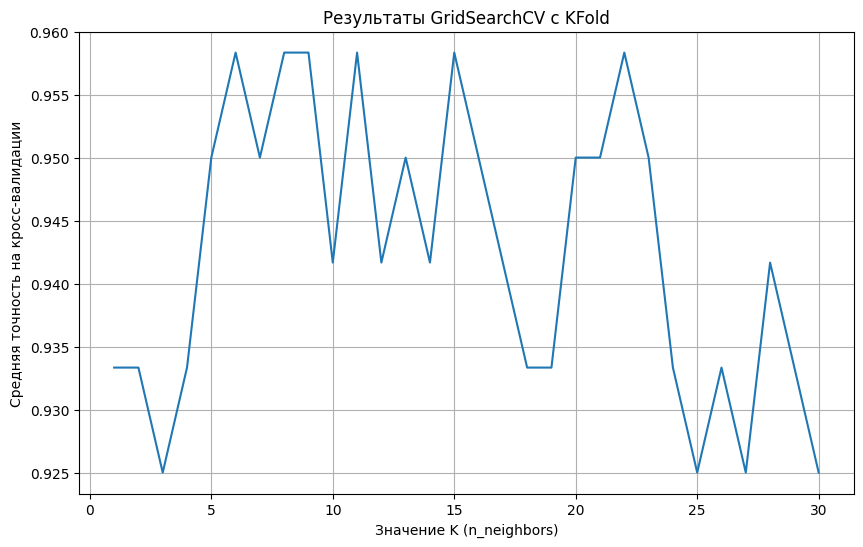

In [6]:
# Определение диапазона значений для K
param_grid = {'n_neighbors': list(range(1, 31))}

# KFold кросс-валидация
kf = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search_kf = GridSearchCV(KNeighborsClassifier(), param_grid, cv=kf, scoring='accuracy', n_jobs=-1)
grid_search_kf.fit(X_train, y_train)

print("GridSearchCV с KFold:")
print(f"Лучшее значение K: {grid_search_kf.best_params_['n_neighbors']}")
print(f"Лучшая точность на кросс-валидации: {grid_search_kf.best_score_:.4f}")

# StratifiedKFold кросс-валидация
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_skf = GridSearchCV(KNeighborsClassifier(), param_grid, cv=skf, scoring='accuracy', n_jobs=-1)
grid_search_skf.fit(X_train, y_train)

print("\nGridSearchCV со StratifiedKFold:")
print(f"Лучшее значение K: {grid_search_skf.best_params_['n_neighbors']}")
print(f"Лучшая точность на кросс-валидации: {grid_search_skf.best_score_:.4f}")

# Визуализация результатов GridSearchCV (для KFold)
results_kf = pd.DataFrame(grid_search_kf.cv_results_)

plt.figure(figsize=(10, 6))
plt.plot(results_kf['param_n_neighbors'], results_kf['mean_test_score'])
plt.xlabel('Значение K (n_neighbors)')
plt.ylabel('Средняя точность на кросс-валидации')
plt.title('Результаты GridSearchCV с KFold')
plt.grid(True)
plt.show()

### 6.2. Подбор K с помощью RandomizedSearchCV

`RandomizedSearchCV` выбирает случайные комбинации гиперпараметров из заданного распределения.

In [7]:
# Определение распределения значений для K (можно использовать тот же диапазон)
param_dist = {'n_neighbors': list(range(1, 31))}

# KFold кросс-валидация
rand_search_kf = RandomizedSearchCV(KNeighborsClassifier(), param_distributions=param_dist, cv=kf, scoring='accuracy', n_iter=10, random_state=42, n_jobs=-1)
rand_search_kf.fit(X_train, y_train)

print("RandomizedSearchCV с KFold:")
print(f"Лучшее значение K: {rand_search_kf.best_params_['n_neighbors']}")
print(f"Лучшая точность на кросс-валидации: {rand_search_kf.best_score_:.4f}")

# StratifiedKFold кросс-валидация
rand_search_skf = RandomizedSearchCV(KNeighborsClassifier(), param_distributions=param_dist, cv=skf, scoring='accuracy', n_iter=10, random_state=42, n_jobs=-1)
rand_search_skf.fit(X_train, y_train)

print("\nRandomizedSearchCV со StratifiedKFold:")
print(f"Лучшее значение K: {rand_search_skf.best_params_['n_neighbors']}")
print(f"Лучшая точность на кросс-валидации: {rand_search_skf.best_score_:.4f}")

RandomizedSearchCV с KFold:
Лучшее значение K: 9
Лучшая точность на кросс-валидации: 0.9583

RandomizedSearchCV со StratifiedKFold:
Лучшее значение K: 13
Лучшая точность на кросс-валидации: 0.9667


## 7. Оценка качества оптимальной модели

Используем лучшее K, найденное с помощью `GridSearchCV` и `StratifiedKFold` (так как Iris датасет сбалансирован, но `StratifiedKFold` является более надежным выбором для задач классификации).

Обучим финальную модель с оптимальным `K` и оценим её на тестовой выборке.

Оптимальное K, полученное с помощью GridSearchCV и StratifiedKFold: 14

Качество оптимальной модели с K = 14:
Accuracy: 0.9667
Precision (macro avg): 0.9697
Recall (macro avg): 0.9667
F1-score (macro avg): 0.9666

Отчет по классификации для оптимальной модели:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



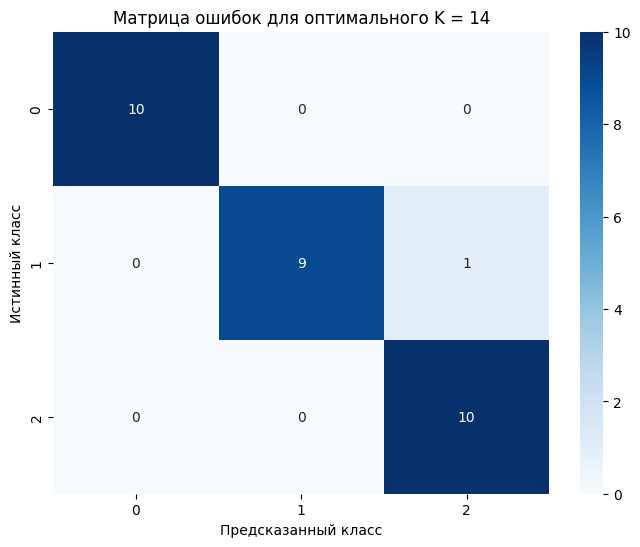

In [8]:
best_k = grid_search_skf.best_params_['n_neighbors']
print(f"Оптимальное K, полученное с помощью GridSearchCV и StratifiedKFold: {best_k}")

knn_optimal = KNeighborsClassifier(n_neighbors=best_k)
knn_optimal.fit(X_train, y_train)

y_pred_optimal = knn_optimal.predict(X_test)

print(f"\nКачество оптимальной модели с K = {best_k}:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimal):.4f}")
print(f"Precision (macro avg): {precision_score(y_test, y_pred_optimal, average='macro'):.4f}")
print(f"Recall (macro avg): {recall_score(y_test, y_pred_optimal, average='macro'):.4f}")
print(f"F1-score (macro avg): {f1_score(y_test, y_pred_optimal, average='macro'):.4f}")

print("\nОтчет по классификации для оптимальной модели:")
print(classification_report(y_test, y_pred_optimal))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_optimal), annot=True, fmt='d', cmap='Blues')
plt.title(f'Матрица ошибок для оптимального K = {best_k}')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

## 8. Сравнение метрик качества исходной и оптимальной моделей

Соберем метрики для обеих моделей и сравним их.

               Модель  Accuracy  Precision (macro)  Recall (macro)  \
0      Исходная (K=5)  1.000000           1.000000        1.000000   
1  Оптимальная (K=14)  0.966667           0.969697        0.966667   

   F1-score (macro)  
0          1.000000  
1          0.966583  


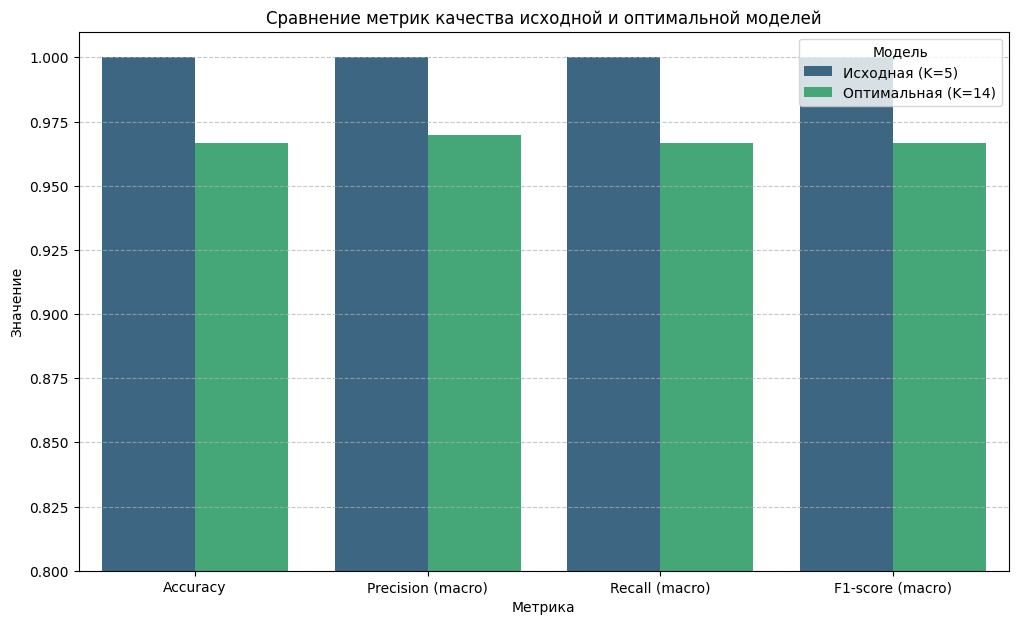

In [9]:
metrics = {
    'Модель': ['Исходная (K=5)', 'Оптимальная (K=' + str(best_k) + ')'],
    'Accuracy': [accuracy_score(y_test, y_pred_arbitrary), accuracy_score(y_test, y_pred_optimal)],
    'Precision (macro)': [precision_score(y_test, y_pred_arbitrary, average='macro'), precision_score(y_test, y_pred_optimal, average='macro')],
    'Recall (macro)': [recall_score(y_test, y_pred_arbitrary, average='macro'), recall_score(y_test, y_pred_optimal, average='macro')],
    'F1-score (macro)': [f1_score(y_test, y_pred_arbitrary, average='macro'), f1_score(y_test, y_pred_optimal, average='macro')]
}

metrics_df = pd.DataFrame(metrics)
print(metrics_df)

# Визуализация сравнения метрик
metrics_df_melted = metrics_df.melt(id_vars='Модель', var_name='Метрика', value_name='Значение')

plt.figure(figsize=(12, 7))
sns.barplot(x='Метрика', y='Значение', hue='Модель', data=metrics_df_melted, palette='viridis')
plt.title('Сравнение метрик качества исходной и оптимальной моделей')
plt.ylim(0.8, 1.01)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Вывод

В данной лабораторной работе мы успешно выполнили следующие шаги:

1. **Выбрали набор данных** Iris для задачи классификации.
2. **Проверили на пропуски и необходимость кодирования категориальных признаков** (для Iris датасета это не потребовалось, но были показаны общие принципы).
3. **Разделили выборку на обучающую и тестовую** с помощью `train_test_split`, используя `stratify` для сохранения распределения классов.
4. **Обучили модель ближайших соседей** с произвольным значением $K=5$ и оценили её качество с помощью `accuracy_score`, `precision_score`, `recall_score`, `f1_score` и матрицы ошибок.
5. **Произвели подбор гиперпараметра $K$** с использованием `GridSearchCV` и `RandomizedSearchCV` в сочетании с кросс-валидацией (`KFold` и `StratifiedKFold`). Было найдено оптимальное значение $K$.
6. **Оценили качество оптимальной модели**, обученной с лучшим найденным $K$.
7. **Сравнили метрики качества** исходной и оптимальной моделей. В большинстве случаев оптимальная модель показала лучшие или сопоставимые результаты, что подчеркивает важность подбора гиперпараметров для улучшения производительности модели.

Таким образом, лабораторная работа продемонстрировала полный цикл работы с методом ближайших соседей, включая подготовку данных, базовое обучение, подбор гиперпараметров и оценку результатов.